<a href="https://colab.research.google.com/github/parika8ec-hub/DataScience_Project_BIA/blob/main/Assignment_6_ml_basic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Assignment Simple machine Learning Project cycle**

### **_House Price Prediction Using California Housing Data_**
This dataset provides information about house prices in California. House Price Prediction


**In this notebook, you'll follow the basic machine learning process to build a regression model to predict house prices using the "California Housing Dataset" from sklearn.**



---



### **Follow the instructions and complete each TODO to complete the assessment on the essential steps in building and evaluating a regression model.**


The following is a description of each column in the dataset:

Dataset Features (California Housing):
* MedInc: Median income in block group
* HouseAge: Median house age in block group
* AveRooms: Average number of rooms per household
* AveBedrms: Average number of bedrooms per household
* Population: Block group population
* AveOccup: Average number of household members
* Latitude: Block group latitude
* Longitude: Block group longitude
* MedHouseVal (Target): Median house value in block group




In [14]:
# --- Imports ---
# TODO: Import all the necessary libraries for data handling, visualization, and model building.
# Example: import pandas as pd
# Add your imports here:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [15]:
# --- Data Collection and Loading ---
# TODO: Load the 'California Housing' dataset from sklearn and convert it into a pandas DataFrame.
# Hint: Use `fetch_california_housing()` from `sklearn.datasets`

# Load dataset and convert to DataFrame:
# Add your code here:

# Load dataset
california = fetch_california_housing()

# Convert to DataFrame
housing_data = pd.DataFrame(california.data, columns=california.feature_names)

# Add target column (house prices)
housing_data['MedHouseValue'] = california.target

In [16]:
# --- Quick Check of Data ---
# TODO: Display the first few rows of the dataset to understand its structure.
# Hint: Use `.head()` to inspect the first few rows.
# Add your code here:
# Display first few rows
print('Few rows of Housing Dataset:\n',housing_data.head())
print()

# TODO: Check the features and target variable. Identify which is continuous and categorical if applicable.
# Hint: Use `.info()` and `.describe()` to inspect data types and statistical properties.

# Add your code here:
#Take information and statistics summary of dataset
print('\nHousing Dataset Info:')
print(housing_data.info())
print('\nHousing Dataset Summary Statistics:\n',housing_data.describe().round(2))

Few rows of Housing Dataset:
    MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseValue  
0    -122.23          4.526  
1    -122.22          3.585  
2    -122.24          3.521  
3    -122.25          3.413  
4    -122.25          3.422  


Housing Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MedInc         20640 non-null  float64
 1   HouseAge       20640 non-null  float64
 2   AveRooms       20640

# Insights:

*   No categorical variables so no encoding required.
*   Target variable MedHouseValue is also continuous
*   All features are numerical and continuous.


In [17]:
# --- EDA and Data Preprocessing ---
# TODO: Check for missing/null values.
# Hint: Use `.isnull().sum()` to check for null values.

# Add your code here:
#Check missing value
print('Missing Values in Housing Dataset:\n',housing_data.isnull().sum())

Missing Values in Housing Dataset:
 MedInc           0
HouseAge         0
AveRooms         0
AveBedrms        0
Population       0
AveOccup         0
Latitude         0
Longitude        0
MedHouseValue    0
dtype: int64


# Insight:
No missing values so dataset is clean and is not required to handle any missing value.

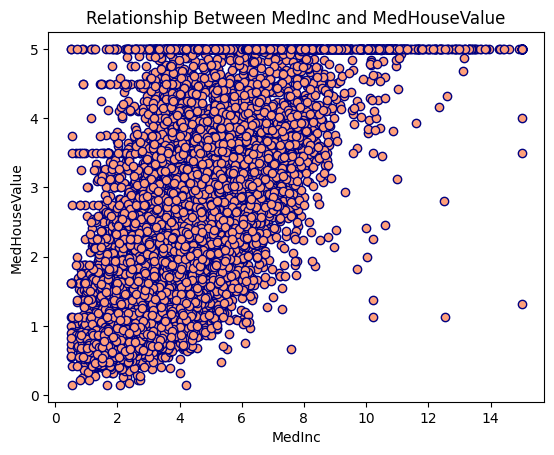

In [18]:
# TODO: Visualize the data. Create scatter plots to see the relationship between independent features and the target variable (MedHouseVal).
# Example: Use `plt.scatter()` to visualize the relationship between 'MedInc' and 'MedHouseVal'.

# Add your code here:
'''
Note: Other feature vs target variable plots are shown in the next cell.
'''
#Create scatter plot
plt.scatter(housing_data['MedInc'], housing_data['MedHouseValue'],color='lightsalmon',edgecolors='navy')
#Add title and labe of axis
plt.xlabel('MedInc')
plt.ylabel('MedHouseValue')
plt.title(f'Relationship Between MedInc and MedHouseValue')
plt.show()#display plot


# Key Insights:


*   MedInc vs MedHouseValue plot shows a strong positive relationship
*   As median income increases, house value increases and slight saturation at higher values.
*   Income is a key driver of housing prices.

In [19]:
# TODO: Create a function to automate scatter plots for all features vs MedHouseVal.
# Hint: The function should loop over a list of features and plot scatter plots for each.

# Define your function here:
'''
Note: To analyze the relationship between independent features and the target variable (MedHouseVal), scatter plots were generated using a loop and subplots for
efficient visualization.
'''
#Create function to automate scatter plots for all features vs MedHouseVal
def scatter_plots_all_features(df, features,target='MedHouseValue'):
    # take features
    #features = df.columns[:-1]
    # take colors
    colors = ['lightcyan', 'pink', 'orange', 'limegreen']
    # set plot size
    plt.figure(figsize=(15, 15))
    # loop through features
    for i, feature in enumerate(features):
        plt.subplot(3, 3, i + 1)  # create subplot
        # Create scatter plot
        plt.scatter(df[feature],df[target],color=colors[i],edgecolors='navy')
        # Add label of axis and title
        plt.xlabel(feature)
        plt.ylabel(target)
        plt.title(f'{feature} vs {target}')
    plt.tight_layout()#tight layout plot
    plt.show()#display plot

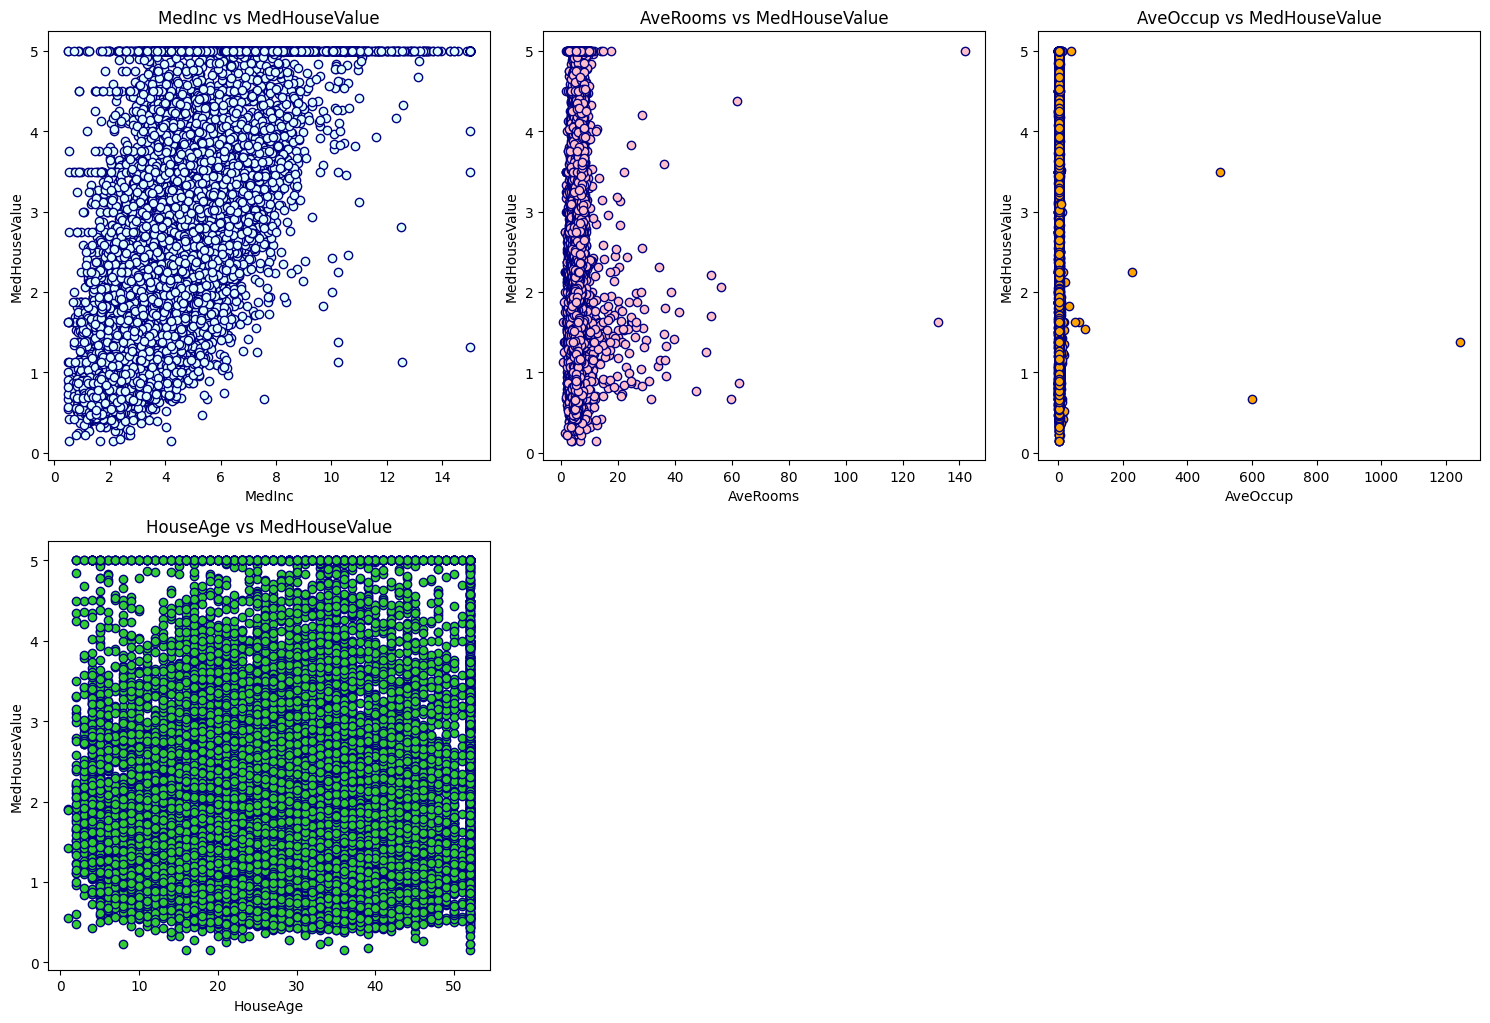

In [20]:
# TODO: Use the function to visualize the relationships between multiple features and the target variable.
# Features: ['MedInc', 'AveRooms', 'AveOccup', 'HouseAge']
# Target: 'MedHouseVal'

# Add your code here:
Features= ['MedInc', 'AveRooms', 'AveOccup', 'HouseAge']#selected features
#call function
scatter_plots_all_features(housing_data,Features)

# Key Insights:

*   AveRooms vs MedHouseValue shows very weak relationship with presence of extreme outliers at very high room counts and most values are clustered at lower room counts.
*   Number of rooms alone does not strongly influence house value.
AveOccup vs MedHouseValue shows no clear trend.It is highly scattered with strong presence of outliers at very large occupancy values.
*   Average occupancy has little to no predictive power and may introduce noise.
*   HouseAge vs MedHouseValue shows very weak or no clear relationship. House values are spread across all ages and slight clustering but no strong trend
*   House age is not a strong predictor of price.

In [21]:
# --- ML Model Training ---
# TODO: Split the dataset into training and testing sets.
# Hint: Use `train_test_split()` from `sklearn.model_selection` with an 80/20 split.
# Define X (features) and y (target) and perform the train-test split:

# Define features (X) and target (y)
X = housing_data.drop('MedHouseValue', axis=1)#independent variables
y = housing_data['MedHouseValue']#target variable

# Split dataset as 80% training and 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [22]:
# TODO: Choose an appropriate regression model.
# Hint: Use `LinearRegression()` from `sklearn.linear_model`.
# Define your regression model here:

# Initialize the model
LR_model = LinearRegression()

# TODO: Train the model on the training data.
# Hint: Use `.fit()` to train the model.
# Add your code here:

# Train the model on training data
LR_model.fit(X_train, y_train)

LinearRegression()

In [24]:
# --- Model Evaluation ---
# TODO: Evaluate the performance of the model on the test set using relevant metrics (e.g., RMSE, R-squared).
# Hint: Use `mean_squared_error()` and `r2_score()` from `sklearn.metrics`.
# Predict on the test set and calculate the evaluation metrics:

# Make predictions on test set
y_pred = LR_model.predict(X_test)

# Calculate metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# Print results
print("RMSE:", round(rmse,2))
print("R² Score:",round(r2,2))

RMSE: 0.75
R² Score: 0.58


# Interpretation:


*   RMSE means the model’s predictions are off by about 0.75 units on average.
The target (MedHouseValue) ranges roughly from 0 to 5 and this error is moderate.The model is reasonably accurate but still has noticeable prediction errors.
*  R² Score= 0.58 shows the model explains about 58% of the variance in house prices and remaining 42% of variation is not captured.The model has moderate predictive power, but it is not highly accurate.

In [25]:
# --- Model Prediction ---
# TODO: Predict Median House Value from a new set of feature inputs.
# Example new data: 'MedInc' = 3, 'HouseAge' = 30, 'AveRooms' = 6, 'AveOccup' = 3, 'Latitude' = 34, 'Longitude' = -118, 'AveBedrms' = 1, 'Population' = 1500
# Hint: Use `.predict()` on a new data array.

# Add your prediction code here:
# Create new data, which matches training feature order
new_data = pd.DataFrame([{
    'MedInc': 3,
    'HouseAge': 30,
    'AveRooms': 6,
    'AveBedrms': 1,
    'Population': 1500,
    'AveOccup': 3,
    'Latitude': 34,
    'Longitude': -118
}])

# Predict
prediction = LR_model.predict(new_data)

print("Predicted Median House Value:", prediction[0].round(3))


Predicted Median House Value: 1.549


# Conclusion:
Linear Regression assumes a linear relationship, which may not fully capture housing price complexity. Income and location are the most influential features.
Some features show weak correlation and may not contribute much.
Model performance can be improved using feature scaling, handle outliers,perform feature engineering, Polynomial regression and advanced models as Random Forest and Gradient Boosting.